# Chapter 16. Qiskit 머신러닝 모델 저장, 로딩 및 연속 학습 (Saving, Loading Qiskit Machine Learning Models and Continuous Training)

이 튜토리얼에서는 Qiskit 머신러닝 모델을 저장하고 로드하는 방법을 보여준다. 모델을 저장하는 능력은 매우 중요하다. 특히 실제 하드웨어에서 모델 훈련에 상당한 시간을 투자할 때 그렇다. 또한 이전에 저장된 모델의 훈련을 재개하는 방법을 보여준다.

이 튜토리얼에서는 다음을 다룬다:

* 간단한 데이터셋을 생성하고, 훈련/테스트 데이터셋으로 분할하고, 그들을 플롯한다
* 모델을 훈련하고 저장한다
* 저장된 모델을 로드하고 훈련을 재개한다
* 모델의 성능을 평가한다
* PyTorch 하이브리드 모델


먼저 필요한 임포트(imports)부터 시작한다. 데이터 준비 단계에서 SciKit-Learn을 많이 사용할 것이다. 다음 셀에서 재현성(reproducibility) 목적으로 난수 시드를 고정한다.


In [1]:
# 필요한 임포트와 난수 시드를 설정한다
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import real_amplitudes
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

from qiskit_machine_learning.algorithms.classifiers import VQC

from IPython.display import clear_output

algorithm_globals.random_seed = 42

두 개의 양자 시뮬레이터, 특히 `Sampler` 프리미티브(primitive)의 두 인스턴스를 사용할 것이다. 첫 번째에서 훈련을 시작한 다음, 두 번째에서 훈련을 재개할 것이다. 이 튜토리얼에서 보여주는 접근 방식은 클라우드에서 이용 가능한 실제 하드웨어에서 모델을 훈련한 후 로컬 시뮬레이터에서 모델을 추론(inference)용으로 재사용하는 데 사용할 수 있다.


In [2]:
# 두 개의 Sampler 인스턴스를 생성한다
sampler1 = Sampler()

sampler2 = Sampler()

## 1. 데이터셋 준비 (Prepare a dataset)

다음 단계는 데이터셋을 준비하는 것이다. 여기서 우리는 다른 튜토리얼과 동일한 방식으로 데이터를 생성한다. 차이점은 생성된 데이터에 일부 변환을 적용한다는 것이다. `40`개의 샘플을 생성하고, 각 샘플은 `2`개의 특성(features)을 가지므로 우리의 특성은 `(40, 2)` 모양의 배열이다. 레이블은 특성을 열 방향으로 합산하여 얻어지며, 합이 `1` 이상이면 이 샘플에 `1`로 레이블이 지정되고 `0`으로 지정된다.


In [3]:
# 데이터 샘플과 레이블을 생성한다
num_samples = 40
num_features = 2
features = 2 * algorithm_globals.random.random([num_samples, num_features]) - 1
labels = 1 * (np.sum(features, axis=1) >= 0)  # in { 0,  1}

다음으로 우리는 SciKit-Learn의 `MinMaxScaler`를 적용하여 우리의 특성을 `[0, 1]` 범위로 축소한다. 이 변환이 적용되면 모델 훈련 수렴이 더 잘 된다.


In [4]:
# 특성을 [0, 1] 범위로 스케일링한다
features = MinMaxScaler().fit_transform(features)
features.shape

(40, 2)

데이터셋의 처음 `5`개 샘플의 특성을 변환 후에 살펴보자.


In [5]:
# 처음 5개 샘플의 특성을 확인한다
features[0:5, :]

array([[0.79067335, 0.44566143],
       [0.88072937, 0.7126244 ],
       [0.06741233, 1.        ],
       [0.7770372 , 0.80422817],
       [0.10351936, 0.45754615]])

우리는 `VQC` 또는 Variational Quantum Classifier를 우리가 훈련할 모델로 선택한다. 이 모델은 기본적으로 원-핫 인코딩된 레이블을 취하므로, `{0, 1}` 집합에 있는 레이블을 원-핫 표현으로 변환해야 한다. 이 변환을 위해서도 SciKit-Learn을 사용한다. 입력 배열을 먼저 `(num_samples, 1)`로 재형성(reshape)해야 한다는 점에 주목하자. `OneHotEncoder` 인코더는 1D 배열에서 작동하지 않으며 우리의 레이블은 1D 배열이다. 이 경우 사용자는 배열이 하나의 특성(우리의 경우!)을 가지는지 또는 하나의 샘플을 가지는지 결정해야 한다. 또한 기본적으로 인코더는 희소 배열을 반환하지만, 데이터셋 플로팅을 위해 조밀한 배열을 사용하는 것이 더 쉬우므로 `sparse`를 `False`로 설정한다.


In [6]:
# 레이블을 원-핫 인코딩한다
labels = OneHotEncoder(sparse_output=False).fit_transform(labels.reshape(-1, 1))
labels.shape

(40, 2)

데이터셋의 처음 `5`개 레이블을 살펴보자. 레이블은 원-핫 인코딩되어야 한다.


In [7]:
# 처음 5개 레이블을 확인한다
labels[0:5, :]

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.]])

이제 우리의 데이터셋을 두 부분으로 분할한다: 훈련 데이터셋과 테스트 데이터셋. 경험상 전체 데이터셋의 80%는 훈련 부분으로, 20%는 테스트 부분으로 들어가야 한다. 우리의 훈련 데이터셋은 `30`개의 샘플을 가진다. 테스트 데이터셋은 모델이 훈련될 때만 한 번 사용되어 모델이 보지 못한 데이터에서 얼마나 잘 작동하는지 확인한다. SciKit-Learn의 `train_test_split`을 사용한다.


In [8]:
# 데이터셋을 훈련/테스트 세트로 분할한다
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=30, random_state=algorithm_globals.random_seed
)
train_features.shape

(30, 2)

이제 우리의 데이터셋이 어떻게 보이는지 볼 시간이다. 그것을 플롯해보자.


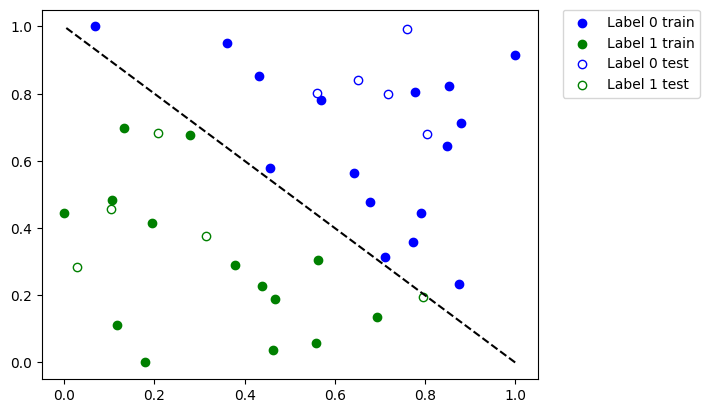

In [9]:
# 데이터셋을 시각화하기 위한 함수를 정의하고 실행한다
def plot_dataset():
    plt.scatter(
        train_features[np.where(train_labels[:, 0] == 0), 0],
        train_features[np.where(train_labels[:, 0] == 0), 1],
        marker="o",
        color="b",
        label="Label 0 train",
    )
    plt.scatter(
        train_features[np.where(train_labels[:, 0] == 1), 0],
        train_features[np.where(train_labels[:, 0] == 1), 1],
        marker="o",
        color="g",
        label="Label 1 train",
    )

    plt.scatter(
        test_features[np.where(test_labels[:, 0] == 0), 0],
        test_features[np.where(test_labels[:, 0] == 0), 1],
        marker="o",
        facecolors="w",
        edgecolors="b",
        label="Label 0 test",
    )
    plt.scatter(
        test_features[np.where(test_labels[:, 0] == 1), 0],
        test_features[np.where(test_labels[:, 0] == 1), 1],
        marker="o",
        facecolors="w",
        edgecolors="g",
        label="Label 1 test",
    )

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
    plt.plot([1, 0], [0, 1], "--", color="black")


plot_dataset()
plt.show()

위의 플롯에서 우리는 다음을 본다:

* 단색 <span style="color:blue">파란색</span> 점들은 `0`으로 레이블된 훈련 데이터셋의 샘플들이다
* 빈 <span style="color:blue">파란색</span> 점들은 `0`으로 레이블된 테스트 데이터셋의 샘플들이다
* 단색 <span style="color:green">초록색</span> 점들은 `1`로 레이블된 훈련 데이터셋의 샘플들이다
* 빈 <span style="color:green">초록색</span> 점들은 `1`로 레이블된 테스트 데이터셋의 샘플들이다

우리는 단색 점들을 사용하여 모델을 훈련하고 빈 점들을 사용하여 모델을 검증한다.


## 2. 모델 훈련 및 저장 (Train a model and save it)

우리는 두 단계로 우리의 모델을 훈련할 것이다. 첫 번째 단계에서 우리는 우리의 모델을 `20`번의 반복(iterations)으로 훈련한다.


In [10]:
# 최대 반복 횟수를 설정한다
maxiter = 20

콜백(callback) 함수가 목적 함수의 값들을 저장하기 위한 빈 배열을 생성한다.


In [11]:
# 목적 함수 값을 저장할 배열을 초기화한다
objective_values = []

Neural Network Classifier & Regressor 튜토리얼에서 콜백 함수를 재사용하여 반복(iteration) 대 목적 함수 값(objective function value)을 플롯한다. 일부 경미한 수정을 가하여 각 단계에서 목적 값들을 플롯한다.


In [12]:
# 콜백 함수와 플롯 설정을 정의한다
# callback function that draws a live plot when the .fit() method is called
def callback_graph(_, objective_value):
    clear_output(wait=True)
    objective_values.append(objective_value)

    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")

    stage1_len = np.min((len(objective_values), maxiter))
    stage1_x = np.linspace(1, stage1_len, stage1_len)
    stage1_y = objective_values[:stage1_len]

    stage2_len = np.max((0, len(objective_values) - maxiter))
    stage2_x = np.linspace(maxiter, maxiter + stage2_len - 1, stage2_len)
    stage2_y = objective_values[maxiter : maxiter + stage2_len]

    plt.plot(stage1_x, stage1_y, color="orange")
    plt.plot(stage2_x, stage2_y, color="purple")
    plt.show()


plt.rcParams["figure.figsize"] = (12, 6)

위에서 언급한 대로 우리는 `VQC` 모델을 훈련하고 `COBYLA`을 선택된 `maxiter` 파라미터 값으로 옵티마이저(optimizer)로 설정한다. 그런 다음 모델의 성능을 평가하여 모델이 얼마나 잘 훈련되었는지 확인한다. 그러면 이 모델을 파일로 저장한다. 두 번째 단계에서 이 모델을 로드하고 계속 작업한다.

여기서 우리는 수동으로 ansatz를 구성하여 최적화를 시작할 초기 지점을 고정한다.


In [13]:
# 옵티마이저와 ansatz를 생성한다
original_optimizer = COBYLA(maxiter=maxiter)

ansatz = real_amplitudes(num_features)
initial_point = np.asarray([0.5] * ansatz.num_parameters)

모델을 생성하고 우리가 이전에 생성한 첫 번째 샘플러로 샘플러를 설정한다.


In [14]:
# VQC 분류기를 생성한다
original_classifier = VQC(
    ansatz=ansatz, optimizer=original_optimizer, callback=callback_graph, sampler=sampler1
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


이제 모델을 훈련할 시간이다.


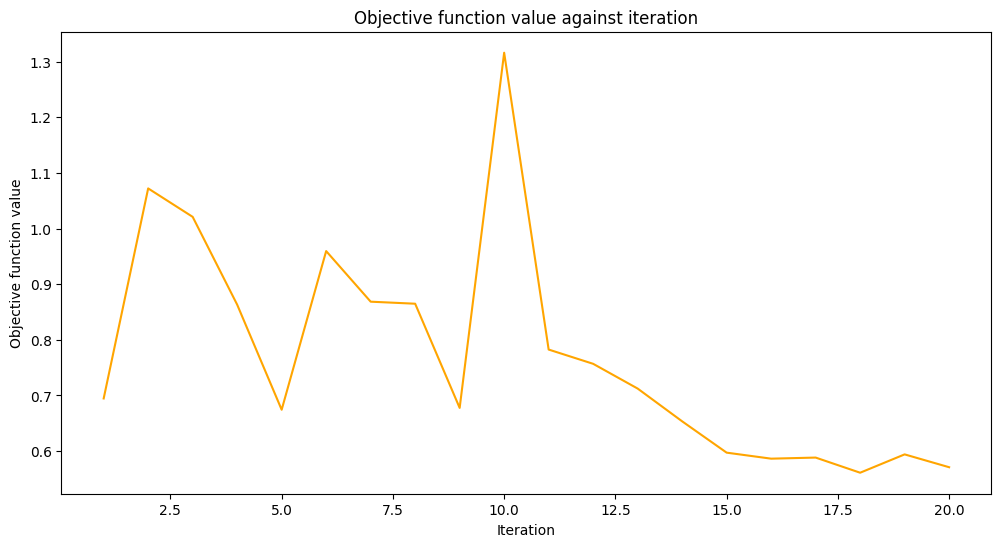

In [15]:
# 모델을 훈련한다
original_classifier.fit(train_features, train_labels)

첫 번째 훈련 단계 후 우리의 모델이 얼마나 잘 수행하는지 보자.


In [16]:
# 훈련 및 테스트 점수를 출력한다
print("Train score", original_classifier.score(train_features, train_labels))
print("Test score ", original_classifier.score(test_features, test_labels))

Train score 0.8
Test score  0.8


다음으로, 우리는 모델을 저장한다. 원하는 파일 이름을 선택할 수 있다. 파일 이름에 지정되지 않은 경우 `save` 메서드가 확장자를 추가하지 않는다는 점에 주목하자.


In [17]:
# 모델을 파일에 저장한다
original_classifier.to_dill("vqc_classifier.model")

## 3. 모델 로드 및 훈련 계속 (Load a model and continue training)

모델을 로드하려면 사용자는 해당 모델 클래스의 클래스 메서드 `load`를 호출해야 한다. 우리의 경우 `VQC`이다. 우리는 이전 섹션에서 모델을 저장할 때 사용한 동일한 파일 이름을 전달한다.


In [18]:
# 저장된 모델을 로드한다
loaded_classifier = VQC.from_dill("vqc_classifier.model")

다음으로, 우리는 모델을 수정하여 추가로 훈련될 수 있고 다른 시뮬레이터에서 훈련될 수 있도록 원한다. 이를 위해 `warm_start` 속성을 설정한다. `True`로 설정되고 `fit()`이 다시 호출되면 모델은 이전 fit의 가중치를 사용하여 새로운 fit을 시작한다. 또한 기본 네트워크의 `sampler` 속성을 튜토리얼 시작에서 생성한 `Sampler` 프리미티브의 두 번째 인스턴스로 설정한다. 마지막으로, `maxiter`이 `80`으로 설정된 새로운 옵티마이저를 생성하고 설정하므로 총 반복 수는 `100`이다.


In [19]:
# 로드된 모델의 설정을 수정하여 계속 훈련할 수 있도록 한다
loaded_classifier.warm_start = True
loaded_classifier.neural_network.sampler = sampler2
loaded_classifier.optimizer = COBYLA(maxiter=80)

이제 우리는 이전 섹션에서 마친 상태로부터 우리의 모델 훈련을 계속한다.


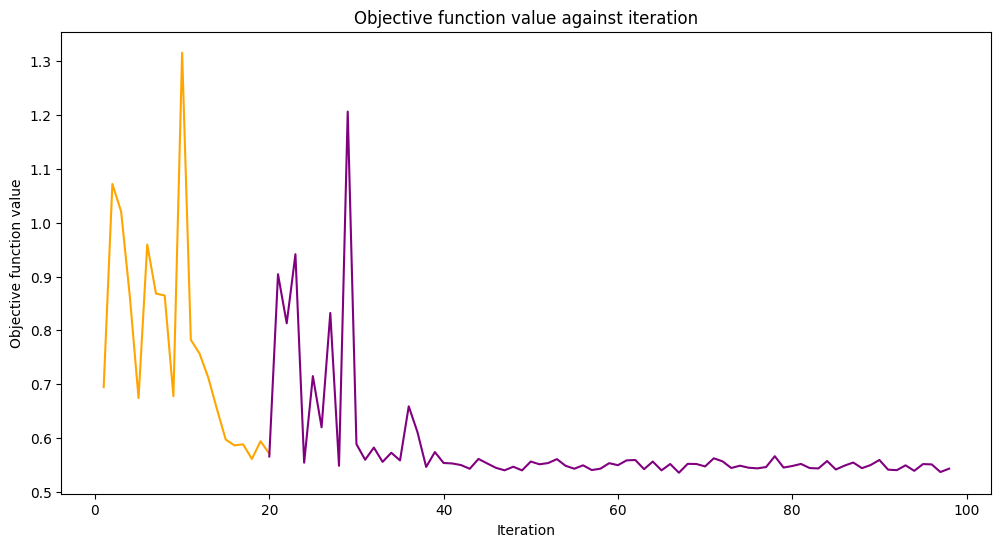

In [20]:
# 로드된 모델로 계속 훈련한다
loaded_classifier.fit(train_features, train_labels)

In [21]:
# 훈련된 모델의 최종 점수를 출력한다
print("Train score", loaded_classifier.score(train_features, train_labels))
print("Test score", loaded_classifier.score(test_features, test_labels))

Train score 0.8666666666666667
Test score 0.8


먼저 어떤 데이터 포인트가 잘못 분류되었는지 보자. 먼저 `predict`을 호출하여 훈련 및 테스트 특성에서 예측된 값들을 추론한다.


In [22]:
# 모델의 예측을 얻는다
train_predicts = loaded_classifier.predict(train_features)
test_predicts = loaded_classifier.predict(test_features)

전체 데이터셋을 플롯하고 잘못 분류된 지점들을 강조한다.


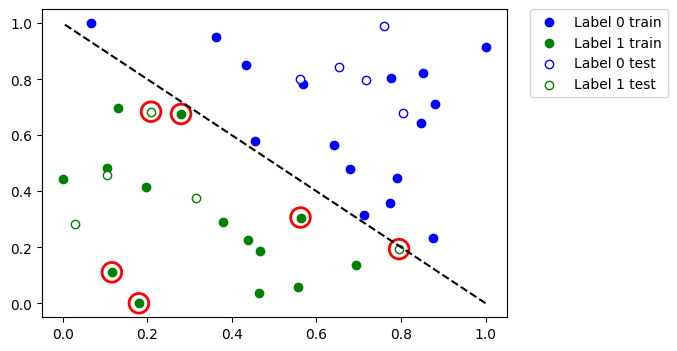

In [23]:
# 잘못 분류된 데이터 포인트를 시각화한다
# return plot to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

plot_dataset()

# plot misclassified data points
plt.scatter(
    train_features[np.all(train_labels != train_predicts, axis=1), 0],
    train_features[np.all(train_labels != train_predicts, axis=1), 1],
    s=200,
    facecolors="none",
    edgecolors="r",
    linewidths=2,
)
plt.scatter(
    test_features[np.all(test_labels != test_predicts, axis=1), 0],
    test_features[np.all(test_labels != test_predicts, axis=1), 1],
    s=200,
    facecolors="none",
    edgecolors="r",
    linewidths=2,
)

따라서 큰 데이터셋이나 큰 모델이 있다면, 이 튜토리얼에서 보여주는 것처럼 여러 단계로 훈련할 수 있다.


## 4. PyTorch 하이브리드 모델 (PyTorch hybrid models)

TorchConnector를 사용할 때 하이브리드 모델을 저장하고 로드하려면 PyTorch 권장 사항을 따라 모델을 저장하고 로드하자. 자세한 내용은 [PyTorch Connector 튜토리얼](05_torch_connector.ipynb)을 참조하자. 여기서 짧은 코드 스니펫이 어떻게 하는지를 보여준다.

이 의사 코드(pseudo-like code)를 살펴보자:
```python
# QNN과 하이브리드 모델을 생성한다
qnn = create_qnn()
model = Net(qnn)
# ... 모델을 훈련한다 ...

# 모델을 저장한다
torch.save(model.state_dict(), "model.pt")

# 새로운 모델을 생성한다
new_qnn = create_qnn()
loaded_model = Net(new_qnn)
loaded_model.load_state_dict(torch.load("model.pt"))
```


In [1]:
# 튜토리얼 마직을 임포트한다
import tutorial_magics

%qiskit_version_table
%qiskit_copyright